In [5]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import reservoirpy as rpy
from reservoirpy.observables import nrmse, rsquare
from pandas import read_csv

rpy.set_seed(42)

In [6]:
data_noise_Lorenz = read_csv('../Dataset/noise_Lorenz_data.csv', usecols=[1, 2, 3])
data_noise_Lorenz = data_noise_Lorenz.values
data_noise_Lorenz = data_noise_Lorenz.astype('float32')

from reservoirpy.datasets import to_forecasting

X = data_noise_Lorenz
x, y = to_forecasting(X, forecast=1)
train_size = 4000
X_train1, y_train1 = x[:train_size], y[:train_size]
X_test1, y_test1 = x[train_size:], y[train_size:]
print(X_train1.shape, y_train1.shape)
print(X_test1.shape, y_test1.shape)

(4000, 3) (4000, 3)
(999, 3) (999, 3)


In [7]:
units = 4000
leak_rate = 0.3
spectral_radius = 1.25
input_scaling = 1.0
connectivity = 0.1
input_connectivity = 0.2
regularization = 1e-8
seed = 1234

def reset_esn():
    from reservoirpy.nodes import Reservoir, Ridge

    reservoir = Reservoir(units, input_scaling=input_scaling, sr=spectral_radius,
                          lr=leak_rate, rc_connectivity=connectivity,
                          input_connectivity=input_connectivity, seed=seed)
    readout   = Ridge(3, ridge=regularization)

    return reservoir >> readout

from reservoirpy.nodes import Reservoir, Ridge

reservoir = Reservoir(units, input_scaling=input_scaling, sr=spectral_radius,
                      lr=leak_rate, rc_connectivity=connectivity,
                      input_connectivity=input_connectivity, seed=seed)

readout   = Ridge(3, ridge=regularization)

esn = reservoir >> readout
y = esn(X[0])  # initialisation
esn = esn.fit(X_train1, y_train1)
y_pred1 = esn.run(X_test1)

Running Model-1:   0%|          | 0/1 [00:00<?, ?it/s]

Running Model-1: 4000it [00:00, 8990.84it/s]
Running Model-1: 100%|██████████| 1/1 [00:00<00:00,  2.20it/s]


Fitting node Ridge-1...


Running Model-1: 999it [00:00, 8484.01it/s]           


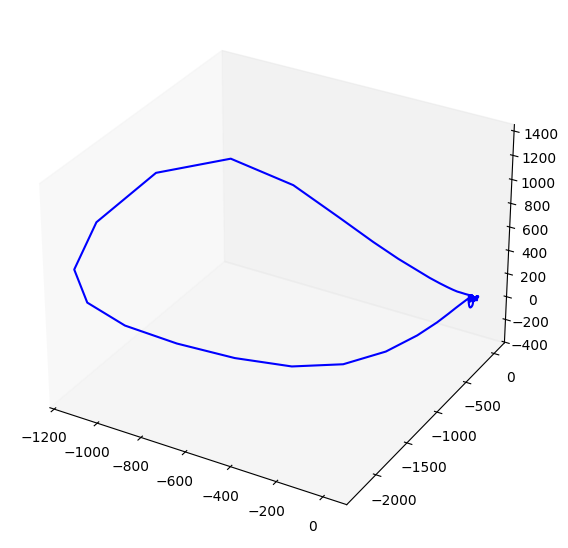

In [8]:
N = y_pred1.shape[0]
Y2 = y_test1
Y1 = y_pred1

fig = plt.figure(figsize=(15, 7))
ax1 = plt.subplot(121, projection='3d')
ax1.plot(Y1[:, 0], Y1[:, 1], Y1[:, 2], color='b')
ax1.grid(False)

# ax2 = plt.subplot(122, projection='3d')
# ax2.plot(Y2[:, 0], Y2[:, 1], Y2[:, 2], color='r')
# ax2.grid(False)